In [6]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


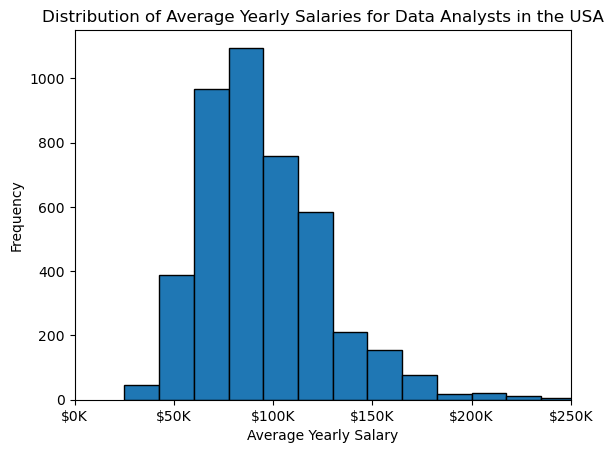

In [19]:
from matplotlib.ticker import FuncFormatter
df_DA_USA= df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()
df_DA_USA['salary_year_avg'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Distribution of Average Yearly Salaries for Data Analysts in the USA")
plt.xlabel("Average Yearly Salary")
plt.xlim(0, 250000)
plt.ylabel("Frequency")

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.show()